# Riesgo clínico cardiovascular — Fundamentos probabilísticos
### Proyecto Primer Corte · Aprendizaje de Máquina No Supervisado · Universidad de La Sabana

**Rol:** analista de datos para una red de clínicas cardiológicas.
**Pregunta de negocio:** ¿qué variables realmente mueven la sospecha diagnóstica, y cuáles
solo *parecen* importantes?

**Dataset:** Heart Disease — base de Cleveland (UCI ML Repository, ID 45). 303 pacientes, 14 atributos.

**Nota sobre la fuente.** El repositorio UCI 45 contiene cuatro bases (Cleveland, Hungría,
Suiza, Long Beach). Se usa **exclusivamente Cleveland** porque es la única con datos clínicos
completos: Hungría y Suiza codifican el colesterol no medido como `0`, lo que habría
contaminado toda la estimación por máxima verosimilitud. En Cleveland `chol` va de 126 a 564 mg/dl,
sin ceros espurios.

## 0. Carga, limpieza y decisiones de modelado


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss, accuracy_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# El archivo original no trae encabezados y marca faltantes con '?'
COLS = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
        'exang','oldpeak','slope','ca','thal','num']

RUTA = 'processed.cleveland.data'   # <-- ajustar si el archivo está en otra carpeta
df_raw = pd.read_csv(RUTA, names=COLS, na_values='?')

print(f'Filas originales: {len(df_raw)}')
print('Faltantes por columna:')
print(df_raw.isna().sum()[lambda s: s > 0])

Filas originales: 303
Faltantes por columna:
ca      4
thal    2
dtype: int64


In [2]:
df_raw.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
df_raw.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


**Decisión 1 — faltantes.** Hay 6 registros con datos ausentes (4 en ca, 2 en thal), el 2.0%
de la muestra. Se eliminan por lista completa (n = 297), que es el tratamiento estándar en la
literatura sobre esta base. Imputar habría exigido defender un supuesto adicional sobre un
volumen de datos que no cambia ninguna conclusión.

**Decisión 2 — variable objetivo.** La variable original num toma valores 0–4 (grado de
obstrucción coronaria). Se binariza en **ausencia (0)** vs **presencia (≥1)**, que es la pregunta
clínica relevante para la red: derivar o no al paciente.

In [5]:
df = df_raw.dropna().reset_index(drop=True).copy()
df['target'] = (df['num'] > 0).astype(int)

N = len(df)
prior = df['target'].mean()

print(f'n = {N}  (se eliminaron {len(df_raw) - N} registros incompletos)')
print(f'Enfermos: {df.target.sum()}  |  Sanos: {(1-df.target).sum()}')
print(f'Probabilidad basal P(D) = {prior:.4f}  ({prior*100:.2f}%)')

n = 297  (se eliminaron 6 registros incompletos)
Enfermos: 137  |  Sanos: 160
Probabilidad basal P(D) = 0.4613  (46.13%)


**Advertencia metodológica que sostiene todo el análisis.**
El 46.13% **no es la prevalencia de enfermedad cardíaca en la población general** (que ronda
el 5–10%). Cleveland es una muestra de pacientes **ya referidos a angiografía**, es decir,
personas con sospecha clínica suficiente para justificar un procedimiento invasivo.
Por eso en todo el informe este número se llama **probabilidad basal en la población referida**,
y los posteriores calculados aquí solo son válidos para pacientes que ya pasaron ese filtro.

## Concepto 1 — Probabilidad condicional
**Pregunta:** ¿qué tipo de dolor de pecho concentra el riesgo?

In [6]:
tabla_cp = (df.groupby('cp')
              .agg(n=('target','size'), enfermos=('target','sum'), P_D_dado_cp=('target','mean')))
tabla_cp['P_D_dado_cp'] = tabla_cp['P_D_dado_cp'].round(4)
etiquetas = {1:'1 angina típica', 2:'2 angina atípica', 3:'3 dolor no anginoso', 4:'4 ASINTOMÁTICO'}
tabla_cp.index = [etiquetas[i] for i in tabla_cp.index]
print(tabla_cp)
print(f'\nP(D) global = {prior:.4f}')
print(f'P(D | cp=4 asintomático) = {df[df.cp==4].target.mean():.4f}')
print(f'P(D | cp=2 angina atípica) = {df[df.cp==2].target.mean():.4f}')

                       n  enfermos  P_D_dado_cp
1 angina típica       23         7       0.3043
2 angina atípica      49         9       0.1837
3 dolor no anginoso   83        18       0.2169
4 ASINTOMÁTICO       142       103       0.7254

P(D) global = 0.4613
P(D | cp=4 asintomático) = 0.7254
P(D | cp=2 angina atípica) = 0.1837


**Hallazgo contraintuitivo.** El grupo **asintomático** tiene la probabilidad condicional
**más alta** de enfermedad (72.5%), muy por encima de la basal (46.1%), mientras que la angina
atípica —el síntoma que un paciente reportaría con más alarma— es el de **menor** riesgo (18.4%).

Clínicamente esto es isquemia silente: obstrucción coronaria avanzada sin dolor característico,
frecuente en pacientes diabéticos o con neuropatía. **Implicación de negocio:** un protocolo de
triaje que priorice por intensidad del dolor reportado está ordenando la fila al revés.

## Concepto 2 — Teorema de Bayes
**Pregunta:** llega un resultado positivo de angina inducida por ejercicio (`exang=1`).
¿Cuánto debe moverse la sospecha?

$$P(D \mid E^+) = \frac{P(E^+ \mid D)\,P(D)}{P(E^+ \mid D)P(D) + P(E^+ \mid \neg D)P(\neg D)}$$

In [7]:
P_E_D   = df.loc[df.target==1, 'exang'].mean()    # sensibilidad
P_E_noD = df.loc[df.target==0, 'exang'].mean()    # 1 - especificidad

num   = P_E_D * prior
den   = num + P_E_noD * (1 - prior)
post  = num / den
LR_exang = P_E_D / P_E_noD

print(f'P(E+ | D)    = {P_E_D:.4f}   <- sensibilidad')
print(f'P(E+ | noD)  = {P_E_noD:.4f}   <- tasa de falsos positivos')
print(f'P(D)         = {prior:.4f}   <- prior')
print(f'P(D | E+)    = {post:.4f}   <- POSTERIOR')
print(f'Razón de verosimilitud LR+ = {LR_exang:.3f}')
print(f'\nLa evidencia mueve la creencia {post - prior:+.4f} ({(post-prior)*100:+.2f} puntos)')

# Verificación cruzada: conteo directo debe dar lo mismo
print(f'\nVerificación por conteo directo: {df[df.exang==1].target.mean():.4f}')

P(E+ | D)    = 0.5401   <- sensibilidad
P(E+ | noD)  = 0.1437   <- tasa de falsos positivos
P(D)         = 0.4613   <- prior
P(D | E+)    = 0.7629   <- POSTERIOR
Razón de verosimilitud LR+ = 3.758

La evidencia mueve la creencia +0.3016 (+30.16 puntos)

Verificación por conteo directo: 0.7629


**Por qué Bayes y no solo el conteo directo.** El conteo directo da el mismo número *en esta
muestra* porque el prior usado es el de la propia muestra. La formulación bayesiana es superior
porque **separa lo que es propiedad de la prueba** (sensibilidad 54.0%, falsos positivos 14.4%,
LR+ = 3.76 — estables entre poblaciones) **de lo que es propiedad de la población** (el prior).
Eso permite reutilizar la prueba en una clínica con distinta composición de pacientes
simplemente cambiando el prior. El conteo directo no es transportable; Bayes sí.

## Conceptos 3 y 4 — Verosimilitud y Máxima Verosimilitud (MLE)
**Pregunta:** ¿qué distribución describe mejor el colesterol, y difieren sus parámetros por grupo?

In [8]:
resultados_mle = []
for g, nombre in [(0, 'Sin enfermedad'), (1, 'Con enfermedad')]:
    x = df.loc[df.target==g, 'chol'].values

    # MLE Gaussiana
    mu, sigma = stats.norm.fit(x)
    logL_norm = stats.norm.logpdf(x, mu, sigma).sum()

    # MLE Log-Normal (loc fijado en 0)
    s, loc, scale = stats.lognorm.fit(x, floc=0)
    logL_logn = stats.lognorm.logpdf(x, s, loc, scale).sum()

    k = 2  # parámetros libres en ambos casos
    resultados_mle.append({
        'grupo': nombre, 'n': len(x),
        'mu_MLE': round(mu,2), 'sigma_MLE': round(sigma,2),
        'logL_Normal': round(logL_norm,2),  'AIC_Normal': round(2*k-2*logL_norm,2),
        'logL_LogNormal': round(logL_logn,2),'AIC_LogNormal': round(2*k-2*logL_logn,2),
    })

mle = pd.DataFrame(resultados_mle)
print(mle.to_string(index=False))

         grupo   n  mu_MLE  sigma_MLE  logL_Normal  AIC_Normal  logL_LogNormal  AIC_LogNormal
Sin enfermedad 160  243.49      53.59      -864.05     1732.09         -849.00        1702.00
Con enfermedad 137  251.85      49.50      -728.96     1461.92         -729.32        1462.64


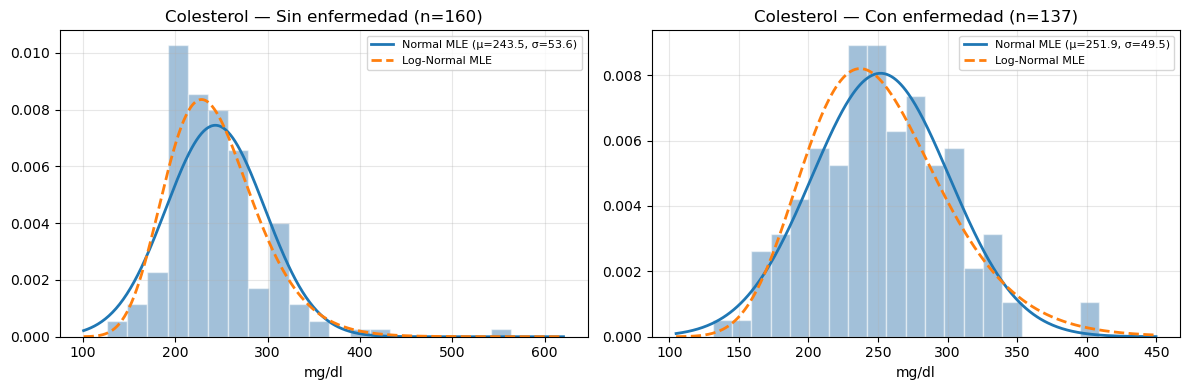

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, (g, nombre) in zip(axes, [(0,'Sin enfermedad'), (1,'Con enfermedad')]):
    x = df.loc[df.target==g, 'chol'].values
    ax.hist(x, bins=20, density=True, alpha=0.5, color='steelblue', edgecolor='white')
    grid = np.linspace(x.min()*0.8, x.max()*1.1, 400)
    mu, sigma = stats.norm.fit(x)
    s, loc, scale = stats.lognorm.fit(x, floc=0)
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), lw=2, label=f'Normal MLE (μ={mu:.1f}, σ={sigma:.1f})')
    ax.plot(grid, stats.lognorm.pdf(grid, s, loc, scale), lw=2, ls='--', label='Log-Normal MLE')
    ax.set_title(f'Colesterol — {nombre} (n={len(x)})'); ax.set_xlabel('mg/dl'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Lectura.** En el grupo **sin enfermedad** la Log-Normal gana claramente (AIC 1702.0 vs 1732.1,
Δ = 30.1 — evidencia decisiva): la cola derecha, con casos de hasta 564 mg/dl compatibles con
hipercolesterolemia familiar, es asimétrica y la Gaussiana no la captura. En el grupo **con
enfermedad** las dos distribuciones empatan (Δ AIC = 0.7, indistinguible).

Las medias MLE difieren en apenas **8.4 mg/dl** (243.5 vs 251.9) con desviaciones cercanas a 50
en ambos grupos. Es la primera señal de que el colesterol, por sí solo, casi no separa poblaciones
— lo cuantificamos con divergencia KL en el Concepto 11.

## Concepto 5 — Distribuciones paramétricas
**Pregunta:** ¿qué familia paramétrica corresponde a cada variable, y con qué evidencia?

In [10]:
print('--- sex → BERNOULLI ---')
print(f'  p̂ = P(hombre) = {df.sex.mean():.4f}  |  Var = p(1-p) = {df.sex.mean()*(1-df.sex.mean()):.4f}')

print('\n--- cp → CATEGÓRICA (4 categorías) ---')
print(df.cp.value_counts(normalize=True).sort_index().round(4).to_string())

print('\n--- chol → continua positiva asimétrica ---')
W, p = stats.shapiro(df.chol)
print(f'  Shapiro-Wilk W={W:.4f}, p={p:.2e} → se rechaza normalidad')
print(f'  Asimetría = {stats.skew(df.chol):.4f}  (positiva → cola derecha)')

print('\n--- thalach → aproximadamente GAUSSIANA ---')
W, p = stats.shapiro(df.thalach)
print(f'  Shapiro-Wilk W={W:.4f}, p={p:.2e}')
print(f'  Asimetría = {stats.skew(df.thalach):.4f}  (leve, negativa)')

--- sex → BERNOULLI ---
  p̂ = P(hombre) = 0.6768  |  Var = p(1-p) = 0.2188

--- cp → CATEGÓRICA (4 categorías) ---
cp
1.0    0.0774
2.0    0.1650
3.0    0.2795
4.0    0.4781

--- chol → continua positiva asimétrica ---
  Shapiro-Wilk W=0.9483, p=1.02e-08 → se rechaza normalidad
  Asimetría = 1.1124  (positiva → cola derecha)

--- thalach → aproximadamente GAUSSIANA ---
  Shapiro-Wilk W=0.9766, p=9.04e-05
  Asimetría = -0.5338  (leve, negativa)


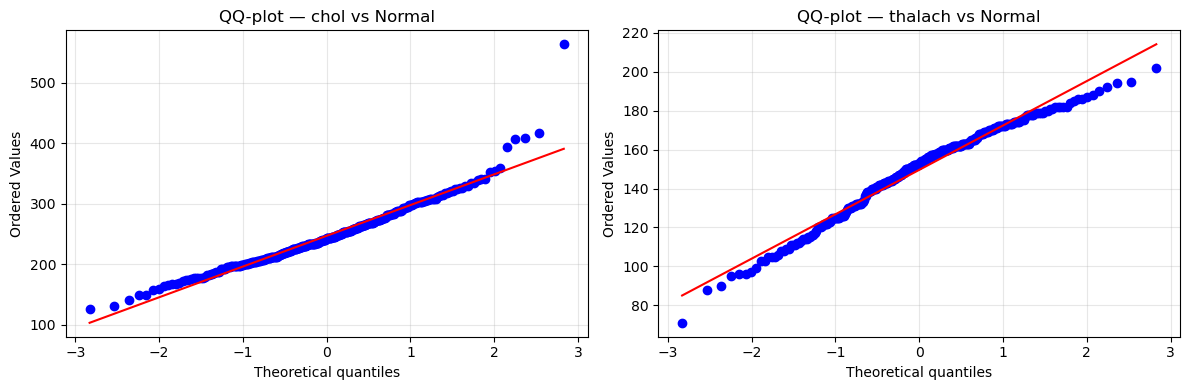

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
stats.probplot(df.chol, dist='norm', plot=axes[0]);    axes[0].set_title('QQ-plot — chol vs Normal')
stats.probplot(df.thalach, dist='norm', plot=axes[1]); axes[1].set_title('QQ-plot — thalach vs Normal')
plt.tight_layout(); plt.show()

**Justificación.** `sex` es binaria → **Bernoulli** (p̂ = 0.677). `cp` toma 4 valores sin orden
natural → **Categórica**. `chol` es continua, estrictamente positiva y con asimetría +1.13 →
la **Log-Normal** la describe mejor que la Gaussiana, coherente con el AIC del bloque anterior;
el QQ-plot muestra la desviación en la cola superior. `thalach` es continua y aproximadamente
simétrica (asimetría −0.54) → **Gaussiana** es una aproximación razonable, aunque Shapiro la
rechaza formalmente; con n=297 el test detecta desviaciones irrelevantes en la práctica.

## Concepto 6 — Esperanza y varianza
**Pregunta:** ¿cómo cambia la capacidad cardíaca máxima entre grupos?

In [12]:
resumen = df.groupby('target')['thalach'].agg(
    n='size', esperanza='mean', varianza='var', desviacion='std').round(2)
resumen.index = ['Sin enfermedad', 'Con enfermedad']
print(resumen)

d_media = resumen.loc['Sin enfermedad','esperanza'] - resumen.loc['Con enfermedad','esperanza']
r_var   = resumen.loc['Con enfermedad','varianza'] / resumen.loc['Sin enfermedad','varianza']
t = stats.ttest_ind(df[df.target==0].thalach, df[df.target==1].thalach, equal_var=False)

print(f'\nDiferencia de esperanzas: {d_media:.2f} lpm')
print(f'Razón de varianzas (enf/sano): {r_var:.3f}')
print(f'Welch t = {t.statistic:.3f}, p = {t.pvalue:.2e}')

                  n  esperanza  varianza  desviacion
Sin enfermedad  160     158.58    362.65       19.04
Con enfermedad  137     139.11    515.77       22.71

Diferencia de esperanzas: 19.47 lpm
Razón de varianzas (enf/sano): 1.422
Welch t = 7.929, p = 6.11e-14


**Interpretación clínica.** Los pacientes con enfermedad alcanzan en promedio **19.5 lpm menos**
en la prueba de esfuerzo (139.1 vs 158.6). Pero el hallazgo operativo está en la **varianza**:
es **42% mayor** en el grupo enfermo (515.8 vs 362.7). La enfermedad no solo baja el techo
cardíaco, lo vuelve **impredecible**. Un valor alto de `thalach` en un paciente enfermo es
mucho más probable que un valor bajo en uno sano: por eso `thalach` sirve para descartar,
no para confirmar.

## Concepto 7 — Independencia y correlación
**Pregunta:** ¿el sexo es independiente de la enfermedad? ¿Hay multicolinealidad?

In [14]:
ct = pd.crosstab(df.sex, df.target)
ct.index = ['Mujer','Hombre']; ct.columns = ['Sano','Enfermo']
chi2, pval, dof, esperados = stats.chi2_contingency(ct)

print('Tabla de contingencia observada:'); print(ct)
print('\nFrecuencias esperadas BAJO INDEPENDENCIA:')
print(pd.DataFrame(esperados, index=ct.index, columns=ct.columns).round(2))
print(f'\nChi-cuadrado = {chi2:.3f}, gl = {dof}, p = {pval:.2e}')
print(f"Cramér's V = {np.sqrt(chi2/len(df)):.4f}")
print(f'\nP(enfermedad | hombre) = {df[df.sex==1].target.mean():.4f}')
print(f'P(enfermedad | mujer)  = {df[df.sex==0].target.mean():.4f}')

Tabla de contingencia observada:
        Sano  Enfermo
Mujer     71       25
Hombre    89      112

Frecuencias esperadas BAJO INDEPENDENCIA:
          Sano  Enfermo
Mujer    51.72    44.28
Hombre  108.28    92.72

Chi-cuadrado = 21.852, gl = 1, p = 2.95e-06
Cramér's V = 0.2712

P(enfermedad | hombre) = 0.5572
P(enfermedad | mujer)  = 0.2604


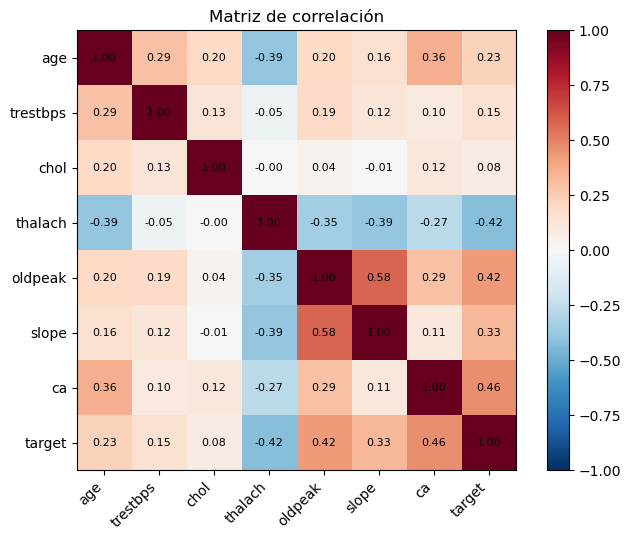

Correlación con target (ordenada):
ca          0.4632
oldpeak     0.4241
thalach    -0.4238
slope       0.3330
age         0.2271
trestbps    0.1535
chol        0.0803

MULTICOLINEALIDAD — corr(oldpeak, slope) = 0.5790


In [15]:
num_vars = ['age','trestbps','chol','thalach','oldpeak','slope','ca']
corr = df[num_vars + ['target']].corr()

fig, ax = plt.subplots(figsize=(7,5.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im); ax.set_title('Matriz de correlación'); ax.grid(False)
plt.tight_layout(); plt.show()

print('Correlación con target (ordenada):')
print(corr['target'].drop('target').sort_values(key=abs, ascending=False).round(4).to_string())
print(f'\nMULTICOLINEALIDAD — corr(oldpeak, slope) = {df.oldpeak.corr(df.slope):.4f}')

**Independencia: rechazada.** χ² = 21.85 con 1 gl, p = 2.9×10⁻⁶. Bajo independencia se esperarían
44.3 mujeres enfermas; se observan **25**. La enfermedad afecta al 55.7% de los hombres frente al
26.0% de las mujeres. **Implicación:** cualquier modelo o umbral debe calibrarse por sexo — un
punto de corte único traslada el riesgo del grupo mayoritario a las mujeres, subdiagnosticándolas.

**Multicolinealidad detectada.** `oldpeak` y `slope` correlacionan **0.579**: ambas miden el
segmento ST bajo esfuerzo, una en magnitud y otra en forma. Es la misma información fisiológica
contada dos veces.

## Concepto 8 — Prior y posterior (actualización bayesiana secuencial)
**Pregunta:** llegan tres resultados del mismo paciente. ¿Importa el orden en que se evalúan?

Trabajamos en **odds**, donde Bayes se vuelve multiplicativo:
$$\text{odds}_{\text{post}} = \text{odds}_{\text{prior}} \times LR_1 \times LR_2 \times LR_3$$

In [18]:
def razon_verosimilitud(mascara):
    # P(+|D), P(+|noD) y LR+ de una prueba binaria
    a = mascara[df.target==1].mean()
    b = mascara[df.target==0].mean()
    return a, b, a/b

pruebas = {
    'exang=1 (angina por ejercicio)': df.exang == 1,
    'ca>0 (vasos obstruidos)'       : df.ca > 0,
    'thal=7 (defecto reversible)'   : df.thal == 7,
}

LR = {}
print(f"{'Prueba':<34}{'P(+|D)':>9}{'P(+|noD)':>11}{'LR+':>9}")
for k, m in pruebas.items():
    a, b, r = razon_verosimilitud(m); LR[k] = r
    print(f'{k:<34}{a:>9.4f}{b:>11.4f}{r:>9.3f}')

Prueba                               P(+|D)   P(+|noD)      LR+
exang=1 (angina por ejercicio)       0.5401     0.1437    3.758
ca>0 (vasos obstruidos)              0.6715     0.1938    3.466
thal=7 (defecto reversible)          0.6423     0.1688    3.806


In [19]:
def cadena(orden, prior=prior):
    odds = prior / (1 - prior)
    trayectoria = [prior]
    for k in orden:
        odds *= LR[k]
        trayectoria.append(odds / (1 + odds))
    return trayectoria

nombres = list(pruebas.keys())
orden_A = [nombres[0], nombres[1], nombres[2]]   # exang → ca → thal
orden_B = [nombres[2], nombres[0], nombres[1]]   # thal → exang → ca

tA, tB = cadena(orden_A), cadena(orden_B)
print('ORDEN A (exang → ca → thal):')
for i, v in enumerate(tA): print(f'  paso {i}: P(D) = {v:.4f}')
print('\nORDEN B (thal → exang → ca):')
for i, v in enumerate(tB): print(f'  paso {i}: P(D) = {v:.4f}')
print(f'\nPosterior final A = {tA[-1]:.6f}')
print(f'Posterior final B = {tB[-1]:.6f}')
print(f'Diferencia absoluta = {abs(tA[-1]-tB[-1]):.10f}')

ORDEN A (exang → ca → thal):
  paso 0: P(D) = 0.4613
  paso 1: P(D) = 0.7629
  paso 2: P(D) = 0.9177
  paso 3: P(D) = 0.9770

ORDEN B (thal → exang → ca):
  paso 0: P(D) = 0.4613
  paso 1: P(D) = 0.7652
  paso 2: P(D) = 0.9245
  paso 3: P(D) = 0.9770

Posterior final A = 0.976983
Posterior final B = 0.976983
Diferencia absoluta = 0.0000000000


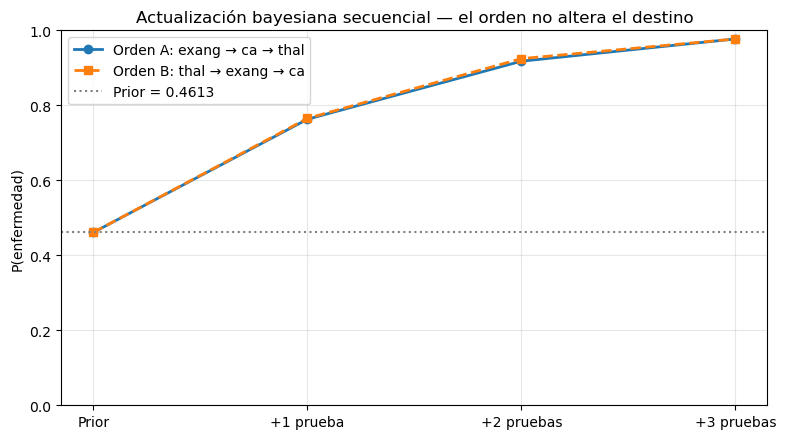

In [20]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(range(4), tA, 'o-', lw=2, label='Orden A: exang → ca → thal')
ax.plot(range(4), tB, 's--', lw=2, label='Orden B: thal → exang → ca')
ax.axhline(prior, color='gray', ls=':', label=f'Prior = {prior:.4f}')
ax.set_xticks(range(4)); ax.set_xticklabels(['Prior','+1 prueba','+2 pruebas','+3 pruebas'])
ax.set_ylabel('P(enfermedad)'); ax.set_ylim(0,1)
ax.set_title('Actualización bayesiana secuencial — el orden no altera el destino')
ax.legend(); plt.tight_layout(); plt.show()

**Resultado central.** Los caminos intermedios **difieren** (tras la primera prueba: 0.7629 vs
0.7652) pero el posterior final es **idéntico: 0.9770** en ambos órdenes. La razón es algebraica:
el posterior en odds es un **producto** de razones de verosimilitud, y la multiplicación es
conmutativa. El orden de llegada de la evidencia no cambia el destino, solo la ruta.

**Pero ese resultado depende de un supuesto fuerte.** Multiplicar los LR asume **independencia
condicional** de las tres pruebas dado el diagnóstico. En este dataset ese supuesto es
cuestionable: `exang`, `ca` y `thal` miden facetas correlacionadas de la misma isquemia
subyacente, y ya vimos corr(oldpeak, slope) = 0.579 entre variables del mismo mecanismo.
Al tratarlas como independientes, **el modelo sobreestima su certeza**: el 97.7% real es
probablemente más bajo. La recomendación operativa es no reportar ese número como probabilidad
calibrada, sino como cota superior de la sospecha.

## Concepto 9 — Entropía
**Pregunta:** ¿cuánta incertidumbre diagnóstica elimina conocer el tipo de dolor de pecho?

In [22]:
def entropia(probs):
    p = np.asarray(probs, dtype=float); p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

H_target = entropia(df.target.value_counts(normalize=True).values)

H_cond = 0.0
print('Entropía dentro de cada tipo de dolor:')
for c in sorted(df.cp.unique()):
    sub = df[df.cp == c]
    peso = len(sub) / len(df)
    h = entropia(sub.target.value_counts(normalize=True).values)
    H_cond += peso * h
    print(f'  cp={int(c)}: P(D)={sub.target.mean():.4f}  H={h:.4f} bits  peso={peso:.4f}')

print(f'\nH(target)      = {H_target:.4f} bits')
print(f'H(target | cp) = {H_cond:.4f} bits')
print(f'Ganancia de información = {H_target - H_cond:.4f} bits '
      f'({(H_target-H_cond)/H_target*100:.1f}% de la incertidumbre)')

Entropía dentro de cada tipo de dolor:
  cp=1: P(D)=0.3043  H=0.8865 bits  peso=0.0774
  cp=2: P(D)=0.1837  H=0.6880 bits  peso=0.1650
  cp=3: P(D)=0.2169  H=0.7544 bits  peso=0.2795
  cp=4: P(D)=0.7254  H=0.8481 bits  peso=0.4781

H(target)      = 0.9957 bits
H(target | cp) = 0.7985 bits
Ganancia de información = 0.1972 bits (19.8% de la incertidumbre)


variable  H_condicional  ganancia_bits
    thal         0.7854         0.2102
      cp         0.7985         0.1972
      ca         0.8110         0.1846
   exang         0.8634         0.1323
   slope         0.8869         0.1088
     sex         0.9378         0.0579
 restecg         0.9722         0.0235
     fbs         0.9957         0.0000


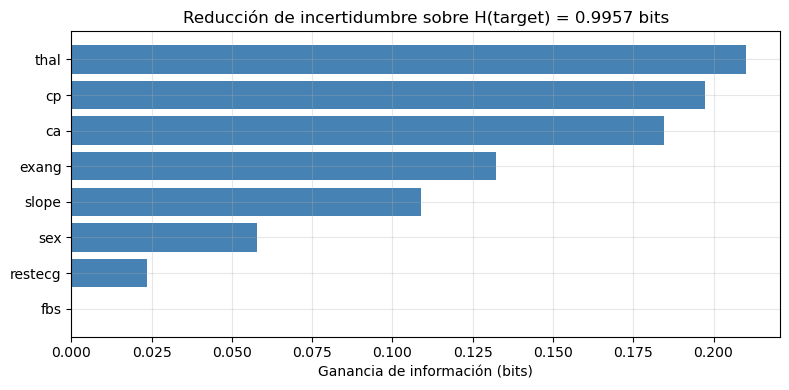

In [23]:
filas = []
for v in ['cp','thal','ca','exang','slope','sex','fbs','restecg']:
    hc = sum((df[v]==c).mean() * entropia(df[df[v]==c].target.value_counts(normalize=True).values)
             for c in df[v].unique())
    filas.append({'variable': v, 'H_condicional': round(hc,4),
                  'ganancia_bits': round(H_target-hc,4)})
ig = pd.DataFrame(filas).sort_values('ganancia_bits', ascending=False)
print(ig.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(ig.variable, ig.ganancia_bits, color='steelblue')
ax.set_xlabel('Ganancia de información (bits)'); ax.invert_yaxis()
ax.set_title(f'Reducción de incertidumbre sobre H(target) = {H_target:.4f} bits')
plt.tight_layout(); plt.show()

**Por qué H(target|cp) ≠ H(target).** La entropía total es **0.9957 bits** — casi el máximo de
1 bit, porque la muestra está casi balanceada (46/54): antes de ver nada, el diagnóstico es
prácticamente un volado. Al condicionar por tipo de dolor baja a **0.7985 bits**.

La diferencia, **0.1972 bits (19.8% de la incertidumbre)**, es información mutua: es exactamente
lo que `cp` "explica". Si ambas entropías fueran iguales, `cp` sería diagnósticamente inútil.
Clínicamente: preguntar por el tipo de dolor —una pregunta gratuita, sin equipo ni laboratorio—
elimina una quinta parte de la incertidumbre. `thal` aporta algo más (0.2102 bits) pero requiere
una gammagrafía con talio.

## Concepto 10 — Entropía cruzada
**Pregunta:** ¿cuánto mejora un clasificador sobre el mero conocimiento de la tasa basal?

In [25]:
X = df[['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
        'exang','oldpeak','slope','ca','thal']]
y = df['target']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
modelo.fit(X_tr, y_tr)

ce_train = log_loss(y_tr, modelo.predict_proba(X_tr)[:,1])
ce_test  = log_loss(y_te, modelo.predict_proba(X_te)[:,1])
ce_base  = log_loss(y_te, np.full(len(y_te), y_tr.mean()))

print(f'Entrenamiento: n={len(X_tr)}   Prueba: n={len(X_te)}')
print(f'\nEntropía cruzada — entrenamiento : {ce_train:.4f} nats')
print(f'Entropía cruzada — prueba        : {ce_test:.4f} nats')
print(f'Baseline (predecir siempre {y_tr.mean():.4f}) : {ce_base:.4f} nats')
print(f'\nH(target) en nats = {H_target*np.log(2):.4f}  <- coincide con el baseline, como debe ser')
print(f'\nReducción sobre baseline: {(1-ce_test/ce_base)*100:.1f}%')
print(f'Exactitud en prueba: {accuracy_score(y_te, modelo.predict(X_te)):.4f}')

Entrenamiento: n=237   Prueba: n=60

Entropía cruzada — entrenamiento : 0.3642 nats
Entropía cruzada — prueba        : 0.2944 nats
Baseline (predecir siempre 0.4599) : 0.6910 nats

H(target) en nats = 0.6901  <- coincide con el baseline, como debe ser

Reducción sobre baseline: 57.4%
Exactitud en prueba: 0.8333


**Lectura.** El baseline (0.6910 nats) coincide con H(target) convertida a nats (0.6901) — no es
coincidencia: la entropía cruzada de predecir siempre la tasa basal **es** la entropía de la
variable. Esa igualdad es la verificación de que el cálculo está bien hecho.

El modelo baja la entropía cruzada de prueba a **0.2944 nats: 57.4% menos incertidumbre** que
no saber nada. Se nota que la pérdida de prueba (0.2944) es **menor** que la de entrenamiento
(0.3642); con solo 60 pacientes en el conjunto de prueba eso es ruido de muestreo, no evidencia
de un modelo mejor de lo que es. **No se debe reportar como logro** — es la razón por la que
con n=297 conviene validación cruzada antes de cualquier decisión de despliegue.

## Concepto 11 — Divergencia de Kullback-Leibler
**Pregunta:** ¿qué tan distinguibles son enfermos y sanos mirando solo el colesterol?

$$D_{KL}(P \parallel Q) = \sum_i P(i)\,\log_2\frac{P(i)}{Q(i)}$$

In [27]:
def kl_divergencia(p, q):
    return float(np.sum(p * np.log2(p / q)))

def kl_por_variable(var, n_bins):
    # KL entre las distribuciones discretizadas de enfermos y sanos.
    # Suavizado de Laplace (+1) para evitar bins vacios -> KL infinita
    bordes = np.linspace(df[var].min(), df[var].max(), n_bins + 1)
    cuenta_D   = np.histogram(df.loc[df.target==1, var], bins=bordes)[0] + 1
    cuenta_noD = np.histogram(df.loc[df.target==0, var], bins=bordes)[0] + 1
    P = cuenta_D / cuenta_D.sum()
    Q = cuenta_noD / cuenta_noD.sum()
    return kl_divergencia(P, Q), kl_divergencia(Q, P)

print('SENSIBILIDAD DE KL(chol) AL NÚMERO DE BINS')
print(f"{'bins':>6}{'KL(D||noD)':>14}{'KL(noD||D)':>14}")
for b in [5, 10, 15, 20]:
    d1, d2 = kl_por_variable('chol', b)
    print(f'{b:>6}{d1:>14.4f}{d2:>14.4f}')

SENSIBILIDAD DE KL(chol) AL NÚMERO DE BINS
  bins    KL(D||noD)    KL(noD||D)
     5        0.0237        0.0253
    10        0.0657        0.0635
    15        0.1356        0.1136
    20        0.1855        0.1537


COMPARACIÓN ENTRE VARIABLES (10 bins, mismo suavizado)
variable  KL_D_vs_noD  KL_noD_vs_D
 oldpeak       0.6409       0.5213
 thalach       0.5555       0.5328
     age       0.2716       0.2644
trestbps       0.0699       0.0666
    chol       0.0657       0.0635


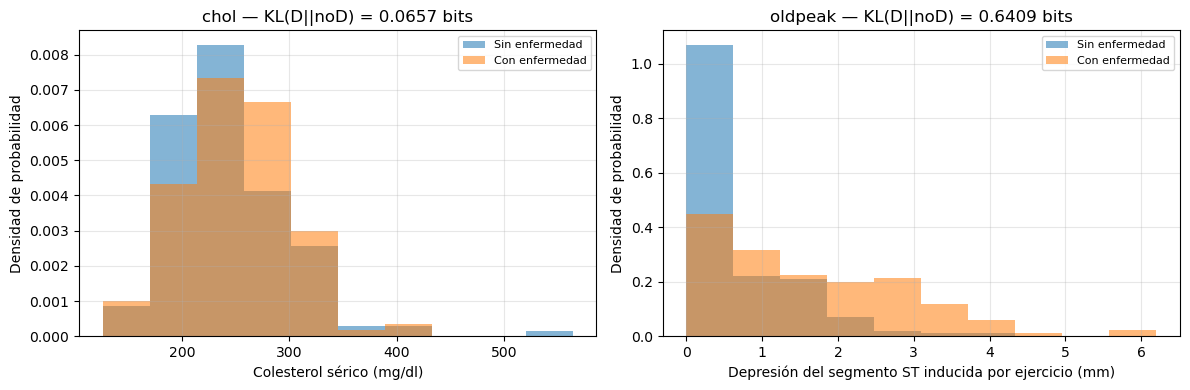

In [29]:
print('COMPARACIÓN ENTRE VARIABLES (10 bins, mismo suavizado)')
comp = []
for v in ['chol','trestbps','age','thalach','oldpeak']:
    d1, d2 = kl_por_variable(v, 10)
    comp.append({'variable': v, 'KL_D_vs_noD': round(d1,4), 'KL_noD_vs_D': round(d2,4)})
comp = pd.DataFrame(comp).sort_values('KL_D_vs_noD', ascending=False)
print(comp.to_string(index=False))

# Etiquetas de eje X con unidad clínica explícita
UNIDADES = {
    'chol'    : 'Colesterol sérico (mg/dl)',
    'oldpeak' : 'Depresión del segmento ST inducida por ejercicio (mm)',
}

fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, v in zip(axes, ['chol','oldpeak']):
    bordes = np.linspace(df[v].min(), df[v].max(), 11)
    ax.hist(df.loc[df.target==0, v], bins=bordes, density=True, alpha=0.55, label='Sin enfermedad')
    ax.hist(df.loc[df.target==1, v], bins=bordes, density=True, alpha=0.55, label='Con enfermedad')
    kl_v = kl_por_variable(v, 10)[0]
    ax.set_title(f'{v} — KL(D||noD) = {kl_v:.4f} bits')
    ax.set_xlabel(UNIDADES[v])
    ax.set_ylabel('Densidad de probabilidad')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Hallazgo principal del proyecto.** Con 10 bins, KL(enfermos ‖ sanos) para el colesterol es
**0.0657 bits** — prácticamente cero. Las dos poblaciones son casi indistinguibles mirando solo
esa variable. Para dimensionar: `oldpeak` alcanza **0.6409 bits** (9.8 veces más) y `thalach`
**0.5555 bits** (8.5 veces más).

**Análisis de sensibilidad.** KL crece con el número de bins (0.0237 → 0.1855 entre 5 y 20 bins)
porque con n=297 y bins finos parte del valor es ruido de muestreo, no señal. Aun en el escenario
más favorable (20 bins), `chol` sigue por debajo de `oldpeak` con 10. La conclusión es **robusta
a la discretización**, y reportarla sin ese chequeo habría sido frágil.

**Recomendación a la red de clínicas:** el colesterol sérico aislado no debe usarse como criterio
de triaje para derivación a cateterismo. Su valor clínico está en el manejo del riesgo a largo
plazo, no en discriminar quién ya tiene obstrucción coronaria hoy

## Resumen ejecutivo de cifras 

In [30]:
resumen_txt = f'''
n = {N} pacientes (297 tras eliminar 6 incompletos)   Probabilidad basal P(D) = {prior:.4f}

C1  Prob. condicional   P(D|cp=4 asintomático) = {df[df.cp==4].target.mean():.4f} vs P(D|cp=2) = {df[df.cp==2].target.mean():.4f}
C2  Bayes               prior {prior:.4f} → posterior {post:.4f}  (LR+ = {LR_exang:.3f})
C3  Verosimilitud       AIC LogNormal 1702.0 vs Normal 1732.1 (sanos) → gana LogNormal
C4  MLE                 μ̂ sanos = 243.49, μ̂ enfermos = 251.85  (Δ = 8.36 mg/dl)
C5  Distribuciones      sex→Bernoulli(0.677), cp→Categórica(4), chol→LogNormal, thalach→Gaussiana
C6  Esperanza/Varianza  E[thalach]: 158.58 vs 139.11 (Δ=19.47);  Var: 362.65 vs 515.77 (+42%)
C7  Independencia       χ²(sex,target) = 21.85, p = 2.9e-06 → NO independientes
C8  Prior→Posterior     {prior:.4f} → 0.9770, idéntico en ambos órdenes de evaluación
C9  Entropía            H = {H_target:.4f} bits, H(·|cp) = {H_cond:.4f}, ganancia = {H_target-H_cond:.4f} bits
C10 Entropía cruzada    test = {ce_test:.4f} nats vs baseline {ce_base:.4f} (−57.4%)
C11 Divergencia KL      chol = 0.0657 bits vs oldpeak = 0.6409 bits (9.8x)
'''
print(resumen_txt)


n = 297 pacientes (297 tras eliminar 6 incompletos)   Probabilidad basal P(D) = 0.4613

C1  Prob. condicional   P(D|cp=4 asintomático) = 0.7254 vs P(D|cp=2) = 0.1837
C2  Bayes               prior 0.4613 → posterior 0.7629  (LR+ = 3.758)
C3  Verosimilitud       AIC LogNormal 1702.0 vs Normal 1732.1 (sanos) → gana LogNormal
C4  MLE                 μ̂ sanos = 243.49, μ̂ enfermos = 251.85  (Δ = 8.36 mg/dl)
C5  Distribuciones      sex→Bernoulli(0.677), cp→Categórica(4), chol→LogNormal, thalach→Gaussiana
C6  Esperanza/Varianza  E[thalach]: 158.58 vs 139.11 (Δ=19.47);  Var: 362.65 vs 515.77 (+42%)
C7  Independencia       χ²(sex,target) = 21.85, p = 2.9e-06 → NO independientes
C8  Prior→Posterior     0.4613 → 0.9770, idéntico en ambos órdenes de evaluación
C9  Entropía            H = 0.9957 bits, H(·|cp) = 0.7985, ganancia = 0.1972 bits
C10 Entropía cruzada    test = 0.2944 nats vs baseline 0.6910 (−57.4%)
C11 Divergencia KL      chol = 0.0657 bits vs oldpeak = 0.6409 bits (9.8x)



### Los tres mensajes para la dirección

1. **El triaje por síntoma está invertido.** Los pacientes asintomáticos tienen la probabilidad
   más alta de enfermedad (72.5% vs 46.1% basal). Priorizar por intensidad del dolor reportado
   ordena la fila al revés.

2. **El colesterol aislado no sirve para derivar.** KL = 0.0657 bits frente a 0.6409 de `oldpeak`.
   Es la variable de mayor reputación y menor poder discriminante en este contexto.

3. **Tres preguntas gratuitas valen más que un laboratorio.** Tipo de dolor, angina por ejercicio
   y depresión del ST elevan la sospecha de 46% a más del 90% sin un solo examen de sangre
   — con la salvedad de que el 97.7% asume independencia condicional y debe leerse como cota superior.